In [21]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# 添付スクリプトからローダー関数をインポート
from golf_range_plotly import load_and_aggregate_trackman_data

# ==========================================
# 0. グローバル描画設定 & モード切り替え
# ==========================================
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# X軸の表示モード切り替え: "day" (Day 1, 2, 3...) または "date" (YYYY-MM-DD)
X_AXIS_MODE = "day"

# ==========================================
# 1. データの読み込みと前処理
# ==========================================
df = load_and_aggregate_trackman_data(".")

# 日付型への変換
df["date"] = pd.to_datetime(df["date"])

# 対象クラブを 7i と 9i に絞り込み
df["Club_clean"] = df["Club-type"].str.lower().str.strip()
df = df[df["Club_clean"].isin(["7i", "9i"])].copy()

# クラブ別データフレームを作成（後続セルで使用）
df_9i = df[df["Club_clean"] == "9i"].copy()
df_7i = df[df["Club_clean"] == "7i"].copy()

# 練習日（セッション）ごとに昇順で連番 Day 1, 2, 3... を付与
unique_dates = sorted(df["date"].unique())
date_to_day = {d: i + 1 for i, d in enumerate(unique_dates)}
df["day_index"] = df["date"].map(date_to_day)
df_9i["day_index"] = df_9i["date"].map(date_to_day)
df_7i["day_index"] = df_7i["date"].map(date_to_day)

# 判定フラグの作成
# (1) 左右ブレ角: ±10° 未満
df["in_h_angle_10"] = df["左右打出角_y"].abs() < 10.0

# (2) 球速: > 35.0 m/s
df["speed_gt_35"] = df["ボールスピード (m/s)"] > 35.0

# (3) チョロ判定: carry < 60 yds かつ peak height < 10 yds
df["is_choro"] = (df["キャリー (yds)"] < 60.0) & (df["最高到達点 (yds)"] < 10.0)

# クラブ別データフレームにも判定フラグを反映
df_9i["in_h_angle_10"] = df_9i["左右打出角_y"].abs() < 10.0
df_9i["speed_gt_35"] = df_9i["ボールスピード (m/s)"] > 35.0
df_9i["is_choro"] = (df_9i["キャリー (yds)"] < 60.0) & (df_9i["最高到達点 (yds)"] < 10.0)
df_7i["in_h_angle_10"] = df_7i["左右打出角_y"].abs() < 10.0
df_7i["speed_gt_35"] = df_7i["ボールスピード (m/s)"] > 35.0
df_7i["is_choro"] = (df_7i["キャリー (yds)"] < 60.0) & (df_7i["最高到達点 (yds)"] < 10.0)

In [22]:
# ==========================================
# 2. 日別・クラブ別の高度指標集計
# ==========================================
def calc_advanced_daily_stats(group):
    valid_angle = group["左右打出角_y"].dropna()
    valid_quality = group.dropna(subset=["打出角 (度)", "キャリー (yds)"])
    valid_speed = group["ボールスピード (m/s)"].dropna()
    valid_carry = group["キャリー (yds)"].dropna()

    return pd.Series(
        {
            "shots": len(group),
            "h_spread_med": valid_angle.abs().median(),
            "quality_rate": (
                (
                    valid_quality["打出角 (度)"].between(18.0, 26.0)
                    & (valid_quality["キャリー (yds)"] >= 70.0)
                ).mean()
                * 100
                if len(valid_quality) > 0
                else np.nan
            ),
            "speed_top20": valid_speed.quantile(0.8) if len(valid_speed) > 0 else np.nan,
            "carry_top20": valid_carry.quantile(0.8) if len(valid_carry) > 0 else np.nan,
        }
    )


# 日別・クラブ別に集計してから、後続セル用の df_9i / df_7i を作成
adv_df = (
    df.groupby(["day_index", "date", "Club_clean"], group_keys=False)
    .apply(calc_advanced_daily_stats)
    .reset_index()
    .sort_values(["day_index", "Club_clean"])
)

df_9i = adv_df[adv_df["Club_clean"] == "9i"].sort_values("day_index").copy()
df_7i = adv_df[adv_df["Club_clean"] == "7i"].sort_values("day_index").copy()

# 既存のイベント図セルとの互換用
df_9i_daily = df_9i.copy()

print(
    "adv_df:",
    len(adv_df),
    "rows, columns:",
    list(adv_df.columns),
)

adv_df: 50 rows, columns: ['day_index', 'date', 'Club_clean', 'shots', 'h_spread_med', 'quality_rate', 'speed_top20', 'carry_top20']


In [23]:

# ==========================================
# 2. 日毎・クラブ別の集計関数
# ==========================================
def calc_daily_stats(group):
    # 左右角データが存在するショットでの割合
    valid_angle = group["左右打出角_y"].dropna()
    h_angle_pct = (
        (group.loc[valid_angle.index, "in_h_angle_10"].sum() / len(valid_angle))
        * 100
        if len(valid_angle) > 0
        else np.nan
    )

    # 球速データが存在するショットでの割合 (> 35 m/s)
    valid_speed = group["ボールスピード (m/s)"].dropna()
    speed_pct = (
        (group.loc[valid_speed.index, "speed_gt_35"].sum() / len(valid_speed))
        * 100
        if len(valid_speed) > 0
        else np.nan
    )

    # チョロ率
    valid_traj = group.dropna(subset=["キャリー (yds)", "最高到達点 (yds)"])
    choro_pct = (
        (valid_traj["is_choro"].sum() / len(valid_traj)) * 100
        if len(valid_traj) > 0
        else np.nan
    )

    # 非チョロショットの抽出
    non_choro = group[~group["is_choro"]]

    # 非チョロ キャリー (yds) 統計量
    c_carries = non_choro["キャリー (yds)"].dropna()
    if len(c_carries) >= 3:
        carry_med = c_carries.median()
        carry_q25 = c_carries.quantile(0.25)
        carry_q75 = c_carries.quantile(0.75)
    else:
        carry_med, carry_q25, carry_q75 = np.nan, np.nan, np.nan

    # 非チョロ ボールスピード (m/s) 統計量
    c_speeds = non_choro["ボールスピード (m/s)"].dropna()
    if len(c_speeds) >= 3:
        speed_med = c_speeds.median()
        speed_q25 = c_speeds.quantile(0.25)
        speed_q75 = c_speeds.quantile(0.75)
    else:
        speed_med, speed_q25, speed_q75 = np.nan, np.nan, np.nan

    return pd.Series(
        {
            "shots": len(group),
            "h_angle_pct": h_angle_pct,
            "speed_pct": speed_pct,
            "choro_pct": choro_pct,
            "carry_med": carry_med,
            "carry_q25": carry_q25,
            "carry_q75": carry_q75,
            "speed_med": speed_med,
            "speed_q25": speed_q25,
            "speed_q75": speed_q75,
        }
    )


# 日付 × Day番号 × クラブ で集約
daily_df = (
    df.groupby(["date", "day_index", "Club_clean"], group_keys=False)
    .apply(calc_daily_stats)
    .reset_index()
)


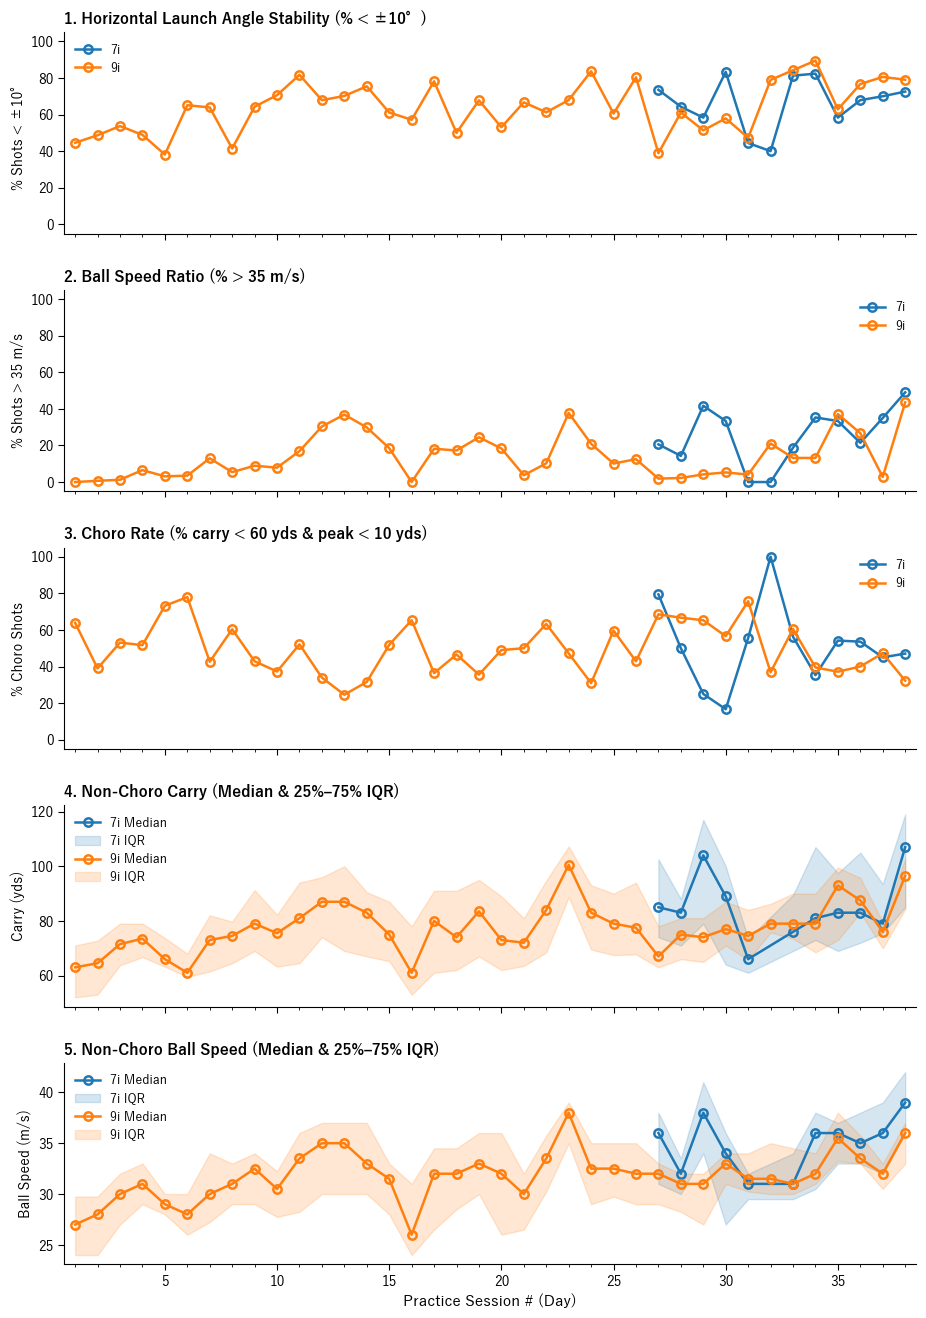

In [24]:

# ==========================================
# 3. Matplotlib プロット設定 (5段)
# ==========================================
fig, axes = plt.subplots(5, 1, figsize=(11, 16), sharex=True)
plt.subplots_adjust(hspace=0.28)

club_styles = {
    "7i": {"color": "#1f77b4", "label": "7i"},
    "9i": {"color": "#ff7f0e", "label": "9i"},
}

x_col = "day_index" if X_AXIS_MODE == "day" else "date"

for club, style in club_styles.items():
    c_df = daily_df[daily_df["Club_clean"] == club].sort_values(x_col)

    # 1. 左右のブレ解析 (< ±10°)
    v1 = c_df.dropna(subset=["h_angle_pct"])
    axes[0].plot(
        v1[x_col],
        v1["h_angle_pct"],
        label=style["label"],
        color=style["color"],
        marker="o",
        markerfacecolor="none",
        markeredgewidth=1.8,
        markersize=6,
        linewidth=1.8,
    )

    # 2. 球速割合 (> 35 m/s)
    v2 = c_df.dropna(subset=["speed_pct"])
    axes[1].plot(
        v2[x_col],
        v2["speed_pct"],
        label=style["label"],
        color=style["color"],
        marker="o",
        markerfacecolor="none",
        markeredgewidth=1.8,
        markersize=6,
        linewidth=1.8,
    )

    # 3. チョロ率
    v3 = c_df.dropna(subset=["choro_pct"])
    axes[2].plot(
        v3[x_col],
        v3["choro_pct"],
        label=style["label"],
        color=style["color"],
        marker="o",
        markerfacecolor="none",
        markeredgewidth=1.8,
        markersize=6,
        linewidth=1.8,
    )

    # 4. 非チョロ キャリー中央値 & 25%–75% IQR
    v4 = c_df.dropna(subset=["carry_med", "carry_q25", "carry_q75"])
    axes[3].plot(
        v4[x_col],
        v4["carry_med"],
        label=f"{style['label']} Median",
        color=style["color"],
        marker="o",
        markerfacecolor="none",
        markeredgewidth=1.8,
        markersize=6,
        linewidth=1.8,
    )
    axes[3].fill_between(
        v4[x_col],
        v4["carry_q25"],
        v4["carry_q75"],
        color=style["color"],
        alpha=0.18,
        label=f"{style['label']} IQR",
    )

    # 5. 非チョロ ボールスピード中央値 & 25%–75% IQR
    v5 = c_df.dropna(subset=["speed_med", "speed_q25", "speed_q75"])
    axes[4].plot(
        v5[x_col],
        v5["speed_med"],
        label=f"{style['label']} Median",
        color=style["color"],
        marker="o",
        markerfacecolor="none",
        markeredgewidth=1.8,
        markersize=6,
        linewidth=1.8,
    )
    axes[4].fill_between(
        v5[x_col],
        v5["speed_q25"],
        v5["speed_q75"],
        color=style["color"],
        alpha=0.18,
        label=f"{style['label']} IQR",
    )

# --- ラベル・タイトルの装飾 ---
titles = [
    "1. Horizontal Launch Angle Stability (% < ±10°)",
    "2. Ball Speed Ratio (% > 35 m/s)",
    "3. Choro Rate (% carry < 60 yds & peak < 10 yds)",
    "4. Non-Choro Carry (Median & 25%–75% IQR)",
    "5. Non-Choro Ball Speed (Median & 25%–75% IQR)",
]
ylabels = [
    "% Shots < ±10°",
    "% Shots > 35 m/s",
    "% Choro Shots",
    "Carry (yds)",
    "Ball Speed (m/s)",
]

for i, ax in enumerate(axes):
    ax.set_title(titles[i], fontsize=11, fontweight="bold", loc="left")
    ax.set_ylabel(ylabels[i], fontsize=10)
    ax.grid(False)
    ax.legend(loc="best", frameon=False, fontsize=9)
    if i < 3:
        ax.set_ylim(-5, 105)

# --- X軸設定（Day / Date 切り替え） ---
if X_AXIS_MODE == "day":
    axes[4].set_xlabel("Practice Session # (Day)", fontsize=11)
    # 5刻みの整数目盛り
    axes[4].xaxis.set_major_locator(ticker.MultipleLocator(5))
    axes[4].xaxis.set_major_formatter(ticker.FormatStrFormatter("%d"))
    axes[4].xaxis.set_minor_locator(ticker.MultipleLocator(1))
    axes[4].set_xlim(0.5, len(unique_dates) + 0.5)
else:
    axes[4].set_xlabel("Calendar Date", fontsize=11)
    axes[4].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    axes[4].xaxis.set_major_locator(mdates.DayLocator(interval=2))
    fig.autofmt_xdate(rotation=30)

plt.show()

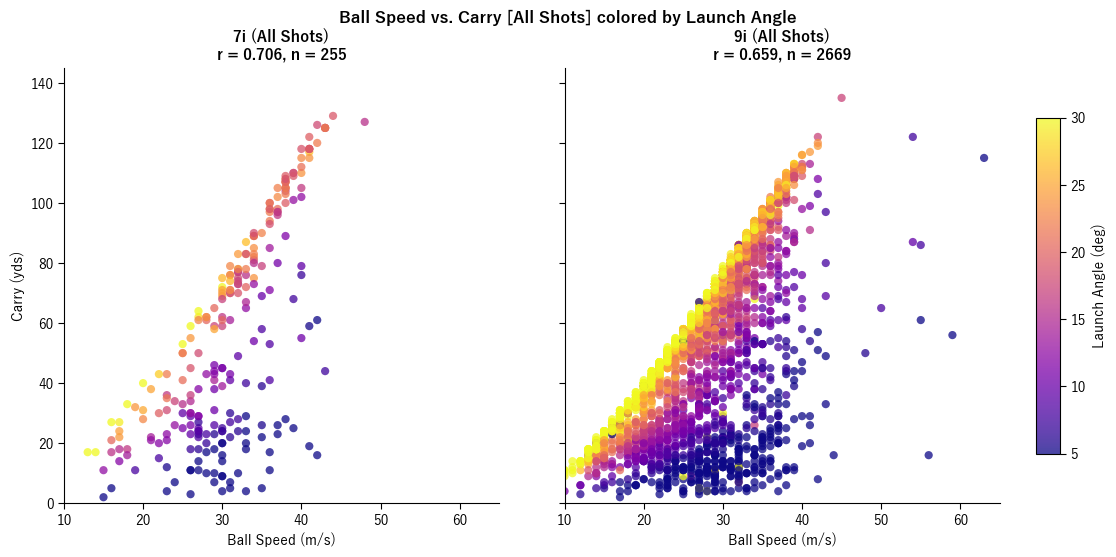

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================
# 1. 全ショットの抽出
# ==========================================
all_scatter_df = df[
    df["ボールスピード (m/s)"].notna()
    & df["キャリー (yds)"].notna()
    & df["打出角 (度)"].notna()
].copy()

# ==========================================
# 2. プロット作成 (7i / 9i 横並び, axis square)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True, sharex=True)

# 右側にカラーバー用のスペースを確保
plt.subplots_adjust(left=0.08, right=0.86, top=0.88, bottom=0.12, wspace=0.15)

clubs = ["7i", "9i"]
cmap = "plasma"
vmin, vmax = 5, 30  # 打出角カラーバーの範囲（度）

for ax, club in zip(axes, clubs):
    sub = all_scatter_df[all_scatter_df["Club_clean"] == club]

    if len(sub) > 0:
        r_val = sub["ボールスピード (m/s)"].corr(sub["キャリー (yds)"])

        sc = ax.scatter(
            sub["ボールスピード (m/s)"],
            sub["キャリー (yds)"],
            c=sub["打出角 (度)"],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            alpha=0.75,
            edgecolors="none",
            s=35,
        )

        ax.set_title(
            f"{club} (All Shots)\nr = {r_val:.3f}, n = {len(sub)}",
            fontweight="bold",
            fontsize=11,
        )
    else:
        ax.set_title(f"{club} (No data)", fontweight="bold")

    ax.set_box_aspect(1)  # 正方形プロット
    ax.set_xlabel("Ball Speed (m/s)", fontsize=10)
    ax.grid(False)

axes[0].set_ylabel("Carry (yds)", fontsize=10)
axes[0].set_xlim(10, 65)
axes[0].set_ylim(0, 145)

# ==========================================
# 3. カラーバーをAxesの外側右に配置
# ==========================================
# 右端（right=0.86）の外側 [left, bottom, width, height] にカラーバー軸を作成
# グラフの高さ（set_box_aspect(1)）の中央に揃えて配置
cbar_ax = fig.add_axes([0.89, 0.22, 0.02, 0.56])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label("Launch Angle (deg)", fontsize=10)

plt.suptitle(
    "Ball Speed vs. Carry [All Shots] colored by Launch Angle",
    fontweight="bold",
    fontsize=12,
    y=0.96,
)

plt.show()

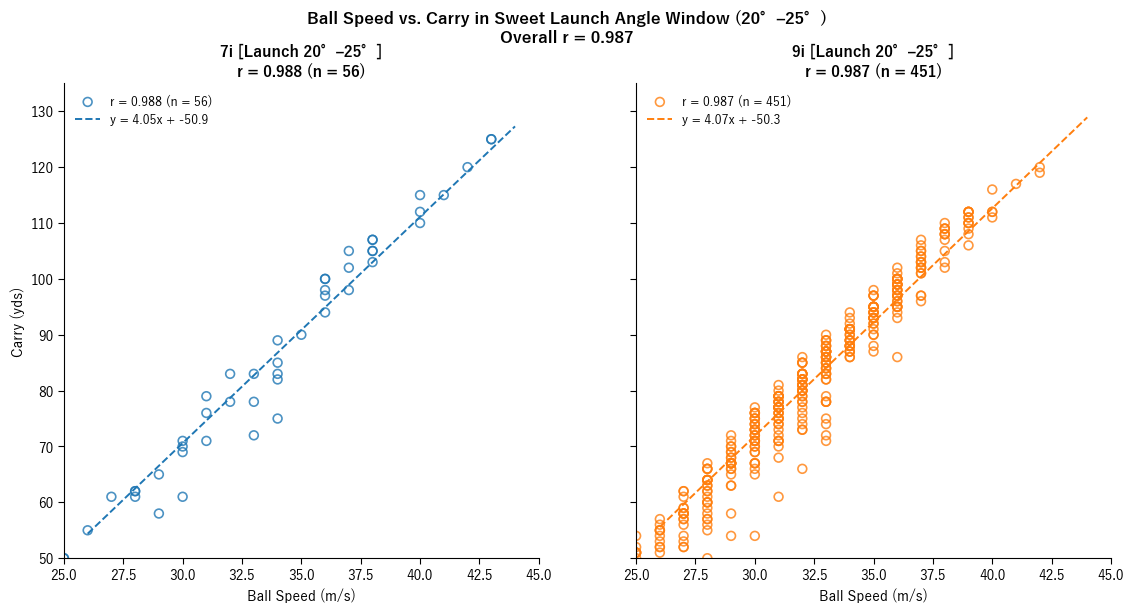

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================
# 1. 打出角 20°〜25° のショット抽出
# ==========================================
sweet_df = all_scatter_df[
    (all_scatter_df["打出角 (度)"] >= 20.0) & (all_scatter_df["打出角 (度)"] <= 25.0)
].copy()

# ==========================================
# 2. プロット作成 (axis square)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True, sharex=True)

clubs = ["7i", "9i"]
club_colors = {"7i": "#1f77b4", "9i": "#ff7f0e"}
r_overall = sweet_df["ボールスピード (m/s)"].corr(sweet_df["キャリー (yds)"])

for ax, club in zip(axes, clubs):
    sub = sweet_df[sweet_df["Club_clean"] == club]

    if len(sub) > 1:
        r_val = sub["ボールスピード (m/s)"].corr(sub["キャリー (yds)"])

        # 散布図（白抜き・オープンサークル）
        ax.scatter(
            sub["ボールスピード (m/s)"],
            sub["キャリー (yds)"],
            color=club_colors[club],
            marker="o",
            facecolors="none",
            edgecolors=club_colors[club],
            s=40,
            linewidths=1.2,
            alpha=0.8,
            label=f"r = {r_val:.3f} (n = {len(sub)})",
        )

        # 線形回帰直線
        slope, intercept = np.polyfit(
            sub["ボールスピード (m/s)"], sub["キャリー (yds)"], 1
        )
        x_vals = np.linspace(26, 44, 100)
        ax.plot(
            x_vals,
            slope * x_vals + intercept,
            color=club_colors[club],
            linestyle="--",
            linewidth=1.4,
            label=f"y = {slope:.2f}x + {intercept:.1f}",
        )

    # アスペクト比を正方形 (1:1) に固定
    ax.set_box_aspect(1)

    ax.set_title(
        f"{club} [Launch 20°–25°]\nr = {r_val:.3f} (n = {len(sub)})",
        fontweight="bold",
        fontsize=11,
    )
    ax.set_xlabel("Ball Speed (m/s)", fontsize=10)
    ax.grid(False)
    ax.legend(frameon=False, loc="upper left", fontsize=9)

axes[0].set_ylabel("Carry (yds)", fontsize=10)

# 軸レンジの統一
axes[0].set_xlim(25, 45)
axes[0].set_ylim(50, 135)

plt.suptitle(
    f"Ball Speed vs. Carry in Sweet Launch Angle Window (20°–25°)\nOverall r = {r_overall:.3f}",
    fontweight="bold",
    fontsize=12,
    y=0.98,
)

plt.tight_layout()
plt.show()

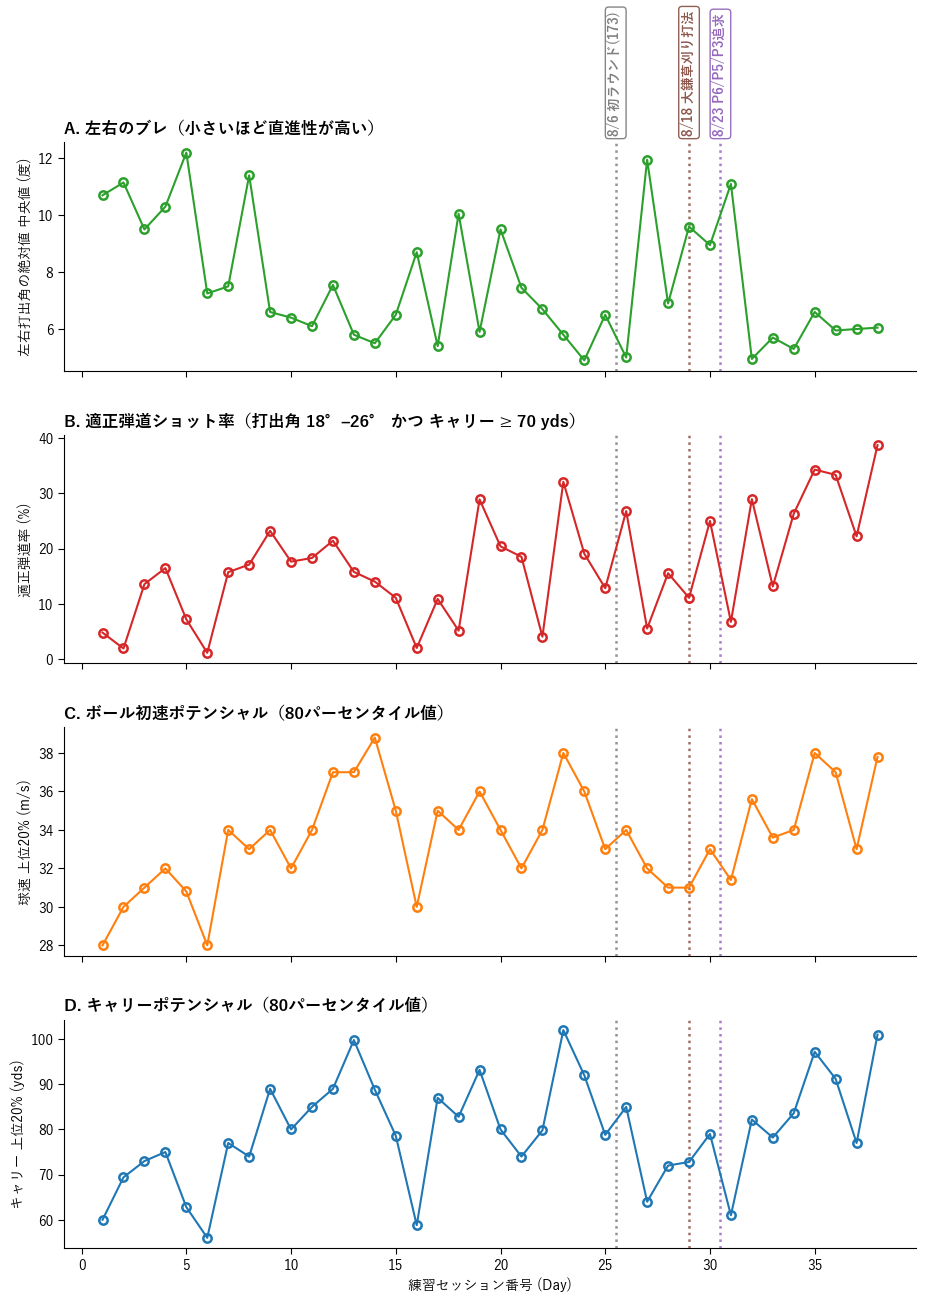

In [28]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# ==========================================
# 0. 日本語フォント設定 (macOS: 游ゴシック)
# ==========================================
plt.rcParams['font.family'] = ['YuGothic', 'Hiragino Sans', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False  # 負号の豆腐防止

# ==========================================
# 1. イベント縦線の座標計算
# ==========================================
day_mapping = (
    df[["day_index", "date"]]
    .drop_duplicates()
    .sort_values("day_index")
    .reset_index(drop=True)
)

target_events = [
    {"target": "08-06", "label": "8/6 初ラウンド(173)", "color": "#7f7f7f"},  # 練習なし
    {"target": "08-18", "label": "8/18 大鎌草刈り打法", "color": "#8c564b"},
    {"target": "08-23", "label": "8/23 P6/P5/P3追求", "color": "#9467bd"},
]

current_year = df["date"].dt.year.max()

event_lines = []
for ev in target_events:
    m_d = ev["target"]
    ev_dt = pd.to_datetime(f"{current_year}-{m_d}")

    matched = day_mapping[day_mapping["date"] == ev_dt]

    if len(matched) > 0:
        day_x = float(matched["day_index"].iloc[0])
    else:
        # 8/6: 直前（7/1）と直後（8/12）の中間に配置
        prev_df = day_mapping[day_mapping["date"] < ev_dt]
        next_df = day_mapping[day_mapping["date"] > ev_dt]

        if len(prev_df) > 0 and len(next_df) > 0:
            x_prev = prev_df["day_index"].iloc[-1]
            x_next = next_df["day_index"].iloc[0]
            day_x = (x_prev + x_next) / 2.0
        else:
            day_x = None

    if day_x is not None:
        event_lines.append(
            {"x": day_x, "label": ev["label"], "color": ev["color"]}
        )

# ==========================================
# 2. プロット作成（上部マージンを拡張）
# ==========================================
fig, axes = plt.subplots(4, 1, figsize=(11, 14), sharex=True)
# ラベルが収まるよう top=0.90 に設定して上部余白を確保
plt.subplots_adjust(top=0.90, hspace=0.28)

# --- 日別集計値をプロット ---
axes[0].plot(
    df_9i_daily["day_index"],
    df_9i_daily["h_spread_med"],
    color="#2ca02c",
    marker="o",
    markerfacecolor="none",
    markeredgewidth=1.8,
)
axes[0].set_ylabel("左右打出角の絶対値 中央値 (度)")
axes[0].set_title(
    "A. 左右のブレ（小さいほど直進性が高い）", fontweight="bold", loc="left"
)

axes[1].plot(
    df_9i_daily["day_index"],
    df_9i_daily["quality_rate"],
    color="#d62728",
    marker="o",
    markerfacecolor="none",
    markeredgewidth=1.8,
)
axes[1].set_ylabel("適正弾道率 (%)")
axes[1].set_title(
    "B. 適正弾道ショット率（打出角 18°–26° かつ キャリー ≥ 70 yds）",
    fontweight="bold",
    loc="left",
)

axes[2].plot(
    df_9i_daily["day_index"],
    df_9i_daily["speed_top20"],
    color="#ff7f0e",
    marker="o",
    markerfacecolor="none",
    markeredgewidth=1.8,
)
axes[2].set_ylabel("球速 上位20% (m/s)")
axes[2].set_title(
    "C. ボール初速ポテンシャル（80パーセンタイル値）", fontweight="bold", loc="left"
)

axes[3].plot(
    df_9i_daily["day_index"],
    df_9i_daily["carry_top20"],
    color="#1f77b4",
    marker="o",
    markerfacecolor="none",
    markeredgewidth=1.8,
)
axes[3].set_ylabel("キャリー 上位20% (yds)")
axes[3].set_title(
    "D. キャリーポテンシャル（80パーセンタイル値）", fontweight="bold", loc="left"
)
axes[3].set_xlabel("練習セッション番号 (Day)")

axes[3].xaxis.set_major_locator(ticker.MultipleLocator(5))
axes[3].xaxis.set_major_formatter(ticker.FormatStrFormatter("%d"))

# ==========================================
# 3. 縦線と枠外・垂直ラベルの描画
# ==========================================
for ev in event_lines:
    x_val = ev["x"]
    for i, ax in enumerate(axes):
        # 縦破線
        ax.axvline(
            x=x_val,
            color=ev["color"],
            linestyle=":",
            linewidth=1.8,
            alpha=0.85,
            zorder=1,
        )

        # 最上段プロット（A）の上枠線から外側へ垂直に配置
        if i == 0:
            ax.text(
                x=x_val,
                y=1.03,  # Y軸 1.0（上枠線）のわずか外側
                s=ev["label"],
                transform=ax.get_xaxis_transform(which="grid"),
                rotation=90,
                va="bottom",  # 下端を 1.03 に合わせ、上に向かって文字を伸ばす
                ha="center",  # 破線の真上に文字の中心を合わせる
                fontsize=9.5,
                fontweight="bold",
                color=ev["color"],
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    fc="white",
                    ec=ev["color"],
                    lw=1.0,
                    alpha=0.95,
                ),
                clip_on=False,  # 枠外描画を許可
            )

for ax in axes:
    ax.grid(False)

plt.show()

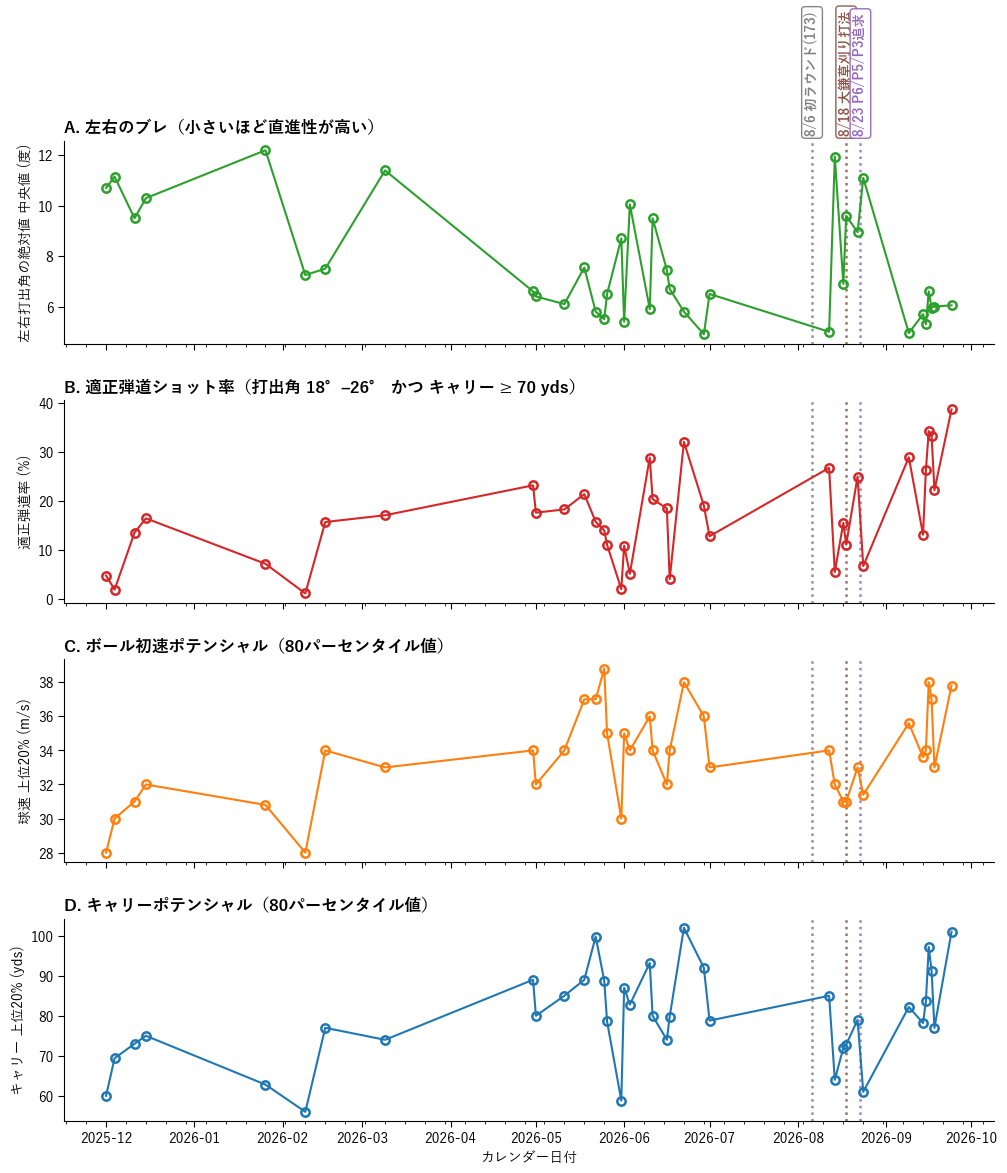

In [29]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================
# 0. 日本語フォント設定 (macOS: 游ゴシック)
# ==========================================
plt.rcParams["font.family"] = ["YuGothic", "Hiragino Sans", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

# ==========================================
# 1. カレンダー日付用イベント縦線の設定
# ==========================================
current_year = df["date"].dt.year.max()

date_events = [
    {
        "date": pd.to_datetime(f"{current_year}-08-06"),
        "label": "8/6 初ラウンド(173)",
        "color": "#7f7f7f",
    },
    {
        "date": pd.to_datetime(f"{current_year}-08-18"),
        "label": "8/18 大鎌草刈り打法",
        "color": "#8c564b",
    },
    {
        "date": pd.to_datetime(f"{current_year}-08-23"),
        "label": "8/23 P6/P5/P3追求",
        "color": "#9467bd",
    },
]

# 9i の日別集計データを日付順にソート
df_9i_date = df_9i_daily.sort_values("date")

# ==========================================
# 2. プロット作成 (X軸: Calendar Date)
# ==========================================
fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)
plt.subplots_adjust(top=0.90, hspace=0.28)

# A. 左右ブレの中央値
axes[0].plot(
    df_9i_date["date"],
    df_9i_date["h_spread_med"],
    color="#2ca02c",
    marker="o",
    markerfacecolor="none",
    markeredgewidth=1.8,
)
axes[0].set_ylabel("左右打出角の絶対値 中央値 (度)")
axes[0].set_title(
    "A. 左右のブレ（小さいほど直進性が高い）", fontweight="bold", loc="left"
)

# B. Quality Shot 達成率
axes[1].plot(
    df_9i_date["date"],
    df_9i_date["quality_rate"],
    color="#d62728",
    marker="o",
    markerfacecolor="none",
    markeredgewidth=1.8,
)
axes[1].set_ylabel("適正弾道率 (%)")
axes[1].set_title(
    "B. 適正弾道ショット率（打出角 18°–26° かつ キャリー ≥ 70 yds）",
    fontweight="bold",
    loc="left",
)

# C. ボール初速 上位20%
axes[2].plot(
    df_9i_date["date"],
    df_9i_date["speed_top20"],
    color="#ff7f0e",
    marker="o",
    markerfacecolor="none",
    markeredgewidth=1.8,
)
axes[2].set_ylabel("球速 上位20% (m/s)")
axes[2].set_title(
    "C. ボール初速ポテンシャル（80パーセンタイル値）", fontweight="bold", loc="left"
)

# D. キャリー 上位20%
axes[3].plot(
    df_9i_date["date"],
    df_9i_date["carry_top20"],
    color="#1f77b4",
    marker="o",
    markerfacecolor="none",
    markeredgewidth=1.8,
)
axes[3].set_ylabel("キャリー 上位20% (yds)")
axes[3].set_title(
    "D. キャリーポテンシャル（80パーセンタイル値）", fontweight="bold", loc="left"
)
axes[3].set_xlabel("カレンダー日付")

# X軸（日付）のフォーマットと目盛り設定
axes[3].xaxis.set_major_locator(mdates.MonthLocator())
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[3].xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
fig.autofmt_xdate(rotation=0, ha="center")

# ==========================================
# 3. 縦線と枠外・垂直ラベルの描画
# ==========================================
for ev in date_events:
    x_dt = ev["date"]
    for i, ax in enumerate(axes):
        # 縦破線
        ax.axvline(
            x=x_dt,
            color=ev["color"],
            linestyle=":",
            linewidth=1.8,
            alpha=0.85,
            zorder=1,
        )

        # 最上段プロット（A）の上枠線から外側へ垂直配置
        if i == 0:
            ax.text(
                x=x_dt,
                y=1.03,
                s=ev["label"],
                transform=ax.get_xaxis_transform(which="grid"),
                rotation=90,
                va="bottom",
                ha="center",
                fontsize=9.5,
                fontweight="bold",
                color=ev["color"],
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    fc="white",
                    ec=ev["color"],
                    lw=1.0,
                    alpha=0.95,
                ),
                clip_on=False,
            )

for ax in axes:
    ax.grid(False)

plt.show()

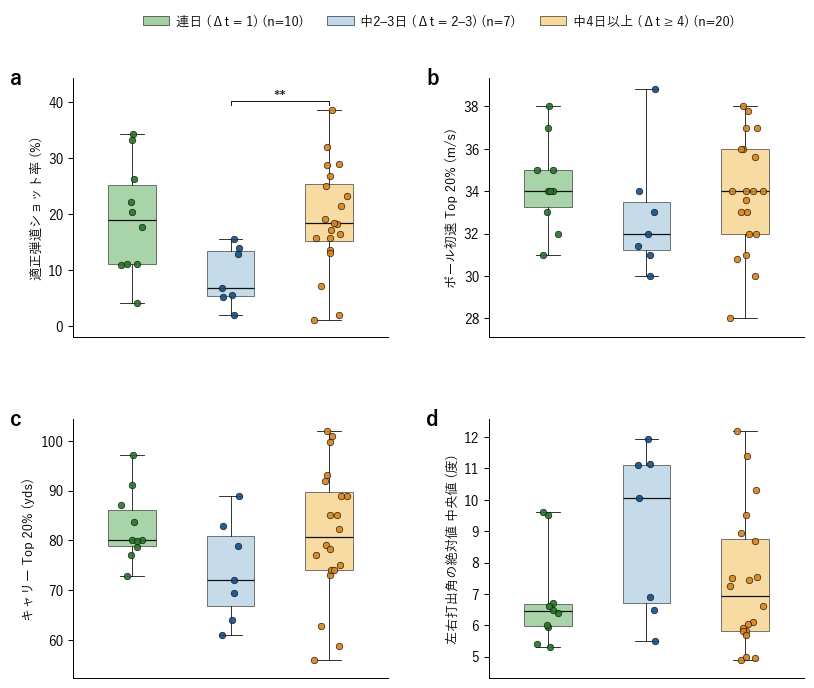

In [31]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# ==========================================
# 0. Nature スタイル グローバル設定
# ==========================================
plt.rcParams["font.family"] = ["YuGothic", "Hiragino Sans", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.linewidth"] = 0.7
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"
plt.rcParams["xtick.major.width"] = 0.7
plt.rcParams["ytick.major.width"] = 0.7
plt.rcParams["xtick.major.size"] = 3.5
plt.rcParams["ytick.major.size"] = 3.5

# ==========================================
# 1. データ準備
# ==========================================
df_interval = df_9i.sort_values("date").copy()
df_interval["delta_days"] = df_interval["date"].diff().dt.days
df_interval = df_interval.dropna(subset=["delta_days"]).copy()


def categorize_interval(days):
    if days == 1:
        return "連日 (Δt = 1)"
    elif 2 <= days <= 3:
        return "中2–3日 (Δt = 2–3)"
    else:
        return "中4日以上 (Δt ≥ 4)"


df_interval["interval_group"] = df_interval["delta_days"].apply(
    categorize_interval
)

group_order = ["連日 (Δt = 1)", "中2–3日 (Δt = 2–3)", "中4日以上 (Δt ≥ 4)"]

# サンプル画像1のカラーパレット準拠（グリーン、ブルー、アンバー）
group_colors = {
    "連日 (Δt = 1)": {
        "box": "#7cbd7c",
        "dot": "#227722",
    },  # Vac+/Inf+ グリーン
    "中2–3日 (Δt = 2–3)": {
        "box": "#a6c8e0",
        "dot": "#104e8b",
    },  # Vac+/Inf- ブルー
    "中4日以上 (Δt ≥ 4)": {
        "box": "#f5c970",
        "dot": "#d98218",
    },  # Vac-/Inf+ アンバー
}

metrics = [
    ("quality_rate", "適正弾道ショット率 (%)"),
    ("speed_top20", "ボール初速 Top 20% (m/s)"),
    ("carry_top20", "キャリー Top 20% (yds)"),
    ("h_spread_med", "左右打出角の絶対値 中央値 (度)"),
]

panel_letters = ["a", "b", "c", "d"]
fig, axes = plt.subplots(2, 2, figsize=(8.5, 7.5))
axes = axes.flatten()
plt.subplots_adjust(
    top=0.88, bottom=0.08, left=0.10, right=0.96, hspace=0.32, wspace=0.32
)


# ==========================================
# 2. ヘルパー関数: 有意差アスタリスクとブラケット
# ==========================================
def p_to_stars(p):
    if p < 0.0001:
        return "****"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def draw_bracket(ax, x1, x2, y, h, text):
    if text == "ns":
        return
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color="#111111", lw=0.7)
    ax.text(
        (x1 + x2) * 0.5,
        y + h,
        text,
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#111111",
    )


# ==========================================
# 3. 各パネルの描画
# ==========================================
for idx, (col, ylabel) in enumerate(metrics):
    ax = axes[idx]
    data_by_group = [
        df_interval[df_interval["interval_group"] == grp][col].dropna().values
        for grp in group_order
    ]

    # --- A. ボックスプロット（半透明・黒枠・黒中央値線） ---
    bp = ax.boxplot(
        data_by_group,
        positions=[1, 2, 3],
        widths=0.48,
        patch_artist=True,
        showfliers=False,
        whis=(0, 100),  # サンプル画像に合わせ min-max までヒゲを伸ばす
        medianprops=dict(color="#111111", linewidth=0.9),
        boxprops=dict(linewidth=0.6, edgecolor="#111111"),
        whiskerprops=dict(color="#111111", linewidth=0.6),
        capprops=dict(color="#111111", linewidth=0.6),
        zorder=2,
    )

    for patch, grp in zip(bp["boxes"], group_order):
        patch.set_facecolor(group_colors[grp]["box"])
        patch.set_alpha(0.65)

    # --- B. ドット散布（Beeswarm風ジッター、前面表示） ---
    np.random.seed(10)
    for pos_idx, (vals, grp) in enumerate(zip(data_by_group, group_order)):
        x_base = pos_idx + 1
        # サンプル画像のような幅のあるジッター
        jitter = np.random.normal(0, 0.075, size=len(vals))
        jitter = np.clip(jitter, -0.18, 0.18)

        ax.scatter(
            x_base + jitter,
            vals,
            s=22,
            facecolors=group_colors[grp]["dot"],
            edgecolors="#111111",
            linewidths=0.5,
            alpha=0.90,
            zorder=3,
        )

    # --- C. 群間検定とブラケット描画 ---
    # 1 vs 2, 2 vs 3, 1 vs 3 の Mann-Whitney U 検定
    p_12 = stats.mannwhitneyu(
        data_by_group[0], data_by_group[1], alternative="two-sided"
    ).pvalue
    p_23 = stats.mannwhitneyu(
        data_by_group[1], data_by_group[2], alternative="two-sided"
    ).pvalue
    p_13 = stats.mannwhitneyu(
        data_by_group[0], data_by_group[2], alternative="two-sided"
    ).pvalue

    # Y軸範囲の自動調整
    all_v = np.concatenate(data_by_group)
    y_min, y_max = np.min(all_v), np.max(all_v)
    y_span = y_max - y_min if y_max != y_min else 1.0

    step = y_span * 0.10
    h_tick = y_span * 0.02
    current_top = y_max + step * 0.2

    # 1 vs 2 (連日 vs 中2–3日)
    if p_to_stars(p_12) != "ns":
        draw_bracket(ax, 1, 2, current_top, h_tick, p_to_stars(p_12))
        current_top += step

    # 2 vs 3 (中2–3日 vs 中4日+)
    if p_to_stars(p_23) != "ns":
        draw_bracket(ax, 2, 3, current_top, h_tick, p_to_stars(p_23))
        current_top += step

    # 1 vs 3 (連日 vs 中4日+)
    if p_to_stars(p_13) != "ns":
        draw_bracket(ax, 1, 3, current_top, h_tick, p_to_stars(p_13))
        current_top += step

    ax.set_ylim(y_min - y_span * 0.08, current_top + step * 0.3)

    # --- D. タイポグラフィと軸のミニマル化 ---
    # 左上のパネル文字（a, b, c, d）
    ax.text(
        -0.20,
        1.04,
        panel_letters[idx],
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
        va="top",
    )
    ax.set_ylabel(ylabel, fontsize=9.5, labelpad=4)

    # X軸は目盛り線を消し、下の余白を詰める
    ax.set_xlim(0.4, 3.6)
    ax.set_xticks([])
    ax.set_xlabel("")
    ax.grid(False)

# ==========================================
# 4. 最上部の横並び凡例 (Nature スタイル)
# ==========================================
legend_handles = [
    mpatches.Patch(
        facecolor=group_colors[grp]["box"],
        edgecolor="#111111",
        linewidth=0.6,
        alpha=0.7,
        label=f"{grp} (n={len(df_interval[df_interval['interval_group']==grp])})",
    )
    for grp in group_order
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.53, 0.98),
    ncol=3,
    frameon=False,
    fontsize=9.5,
    handletextpad=0.5,
    columnspacing=1.8,
)

plt.show()

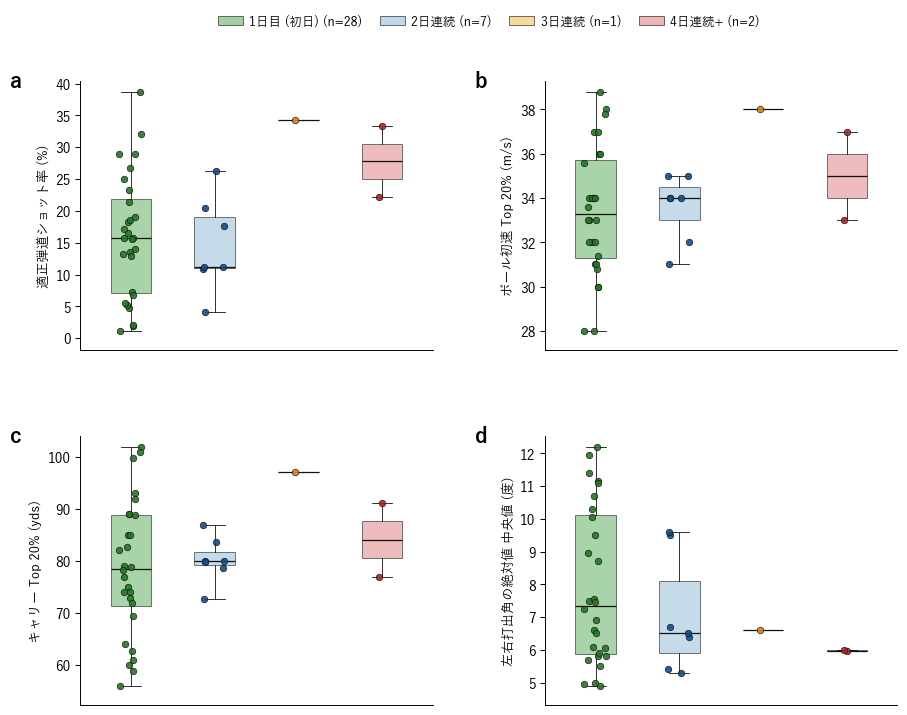

In [32]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# ==========================================
# 0. Nature スタイル グローバル設定
# ==========================================
plt.rcParams["font.family"] = ["YuGothic", "Hiragino Sans", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.linewidth"] = 0.7
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"
plt.rcParams["xtick.major.width"] = 0.7
plt.rcParams["ytick.major.width"] = 0.7
plt.rcParams["xtick.major.size"] = 3.5
plt.rcParams["ytick.major.size"] = 3.5

# ==========================================
# 1. 連続打席ストリーク番号（Consecutive Day）の算出
# ==========================================
df_streak = df_9i.sort_values("date").copy()
df_streak["delta_days"] = df_streak["date"].diff().dt.days

streak_counts = []
current_streak = 1

for i, row in df_streak.iterrows():
    d = row["delta_days"]
    if pd.isna(d) or d > 1:
        current_streak = 1
    else:
        current_streak += 1
    streak_counts.append(current_streak)

df_streak["consecutive_day"] = streak_counts


def categorize_streak(n):
    if n == 1:
        return "1日目 (初日)"
    elif n == 2:
        return "2日連続"
    elif n == 3:
        return "3日連続"
    else:
        return "4日連続+"


df_streak["streak_group"] = df_streak["consecutive_day"].apply(
    categorize_streak
)

streak_order = ["1日目 (初日)", "2日連続", "3日連続", "4日連続+"]

# Nature パレット（緑, 青, 橙, ローズ赤）
streak_colors = {
    "1日目 (初日)": {"box": "#7cbd7c", "dot": "#227722"},  # グリーン
    "2日連続": {"box": "#a6c8e0", "dot": "#104e8b"},  # ブルー
    "3日連続": {"box": "#f5c970", "dot": "#d98218"},  # アンバー
    "4日連続+": {"box": "#e69898", "dot": "#b22222"},  # ローズ赤
}

metrics = [
    ("quality_rate", "適正弾道ショット率 (%)"),
    ("speed_top20", "ボール初速 Top 20% (m/s)"),
    ("carry_top20", "キャリー Top 20% (yds)"),
    ("h_spread_med", "左右打出角の絶対値 中央値 (度)"),
]

panel_letters = ["a", "b", "c", "d"]
fig, axes = plt.subplots(2, 2, figsize=(9.5, 7.8))
axes = axes.flatten()
plt.subplots_adjust(
    top=0.88, bottom=0.08, left=0.10, right=0.96, hspace=0.32, wspace=0.32
)


# ==========================================
# 2. ヘルパー関数: 有意差アスタリスクとブラケット
# ==========================================
def p_to_stars(p):
    if p < 0.0001:
        return "****"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def draw_bracket(ax, x1, x2, y, h, text):
    if text == "ns":
        return
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color="#111111", lw=0.7)
    ax.text(
        (x1 + x2) * 0.5,
        y + h,
        text,
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#111111",
    )


# ==========================================
# 3. 各パネルの描画
# ==========================================
for idx, (col, ylabel) in enumerate(metrics):
    ax = axes[idx]
    data_by_group = [
        df_streak[df_streak["streak_group"] == grp][col].dropna().values
        for grp in streak_order
    ]

    # --- A. ボックスプロット（min-maxウィスカー、半透明塗り、黒細枠線） ---
    bp = ax.boxplot(
        data_by_group,
        positions=[1, 2, 3, 4],
        widths=0.48,
        patch_artist=True,
        showfliers=False,
        whis=(0, 100),
        medianprops=dict(color="#111111", linewidth=0.9),
        boxprops=dict(linewidth=0.6, edgecolor="#111111"),
        whiskerprops=dict(color="#111111", linewidth=0.6),
        capprops=dict(color="#111111", linewidth=0.6),
        zorder=2,
    )

    for patch, grp in zip(bp["boxes"], streak_order):
        patch.set_facecolor(streak_colors[grp]["box"])
        patch.set_alpha(0.65)

    # --- B. ドット散布（Beeswarm風ジッター、前面配置） ---
    np.random.seed(15)
    for pos_idx, (vals, grp) in enumerate(zip(data_by_group, streak_order)):
        x_base = pos_idx + 1
        jitter = np.random.normal(0, 0.075, size=len(vals))
        jitter = np.clip(jitter, -0.17, 0.17)

        ax.scatter(
            x_base + jitter,
            vals,
            s=22,
            facecolors=streak_colors[grp]["dot"],
            edgecolors="#111111",
            linewidths=0.5,
            alpha=0.90,
            zorder=3,
        )

    # --- C. 有意差検定（隣接ペア & 全体比較）とブラケット描画 ---
    all_v = (
        np.concatenate(data_by_group) if len(data_by_group) > 0 else np.array([0])
    )
    y_min, y_max = (
        (np.min(all_v), np.max(all_v)) if len(all_v) > 0 else (0, 10)
    )
    y_span = y_max - y_min if y_max != y_min else 1.0

    step = y_span * 0.10
    h_tick = y_span * 0.02
    current_top = y_max + step * 0.2

    # ペア検定: (1 vs 2), (2 vs 3), (1 vs 3), (1 vs 4)
    pairs_to_test = [(0, 1), (1, 2), (0, 2), (0, 3)]
    for p_idx1, p_idx2 in pairs_to_test:
        d1 = data_by_group[p_idx1]
        d2 = data_by_group[p_idx2]
        if len(d1) >= 2 and len(d2) >= 2:
            pval = stats.mannwhitneyu(d1, d2, alternative="two-sided").pvalue
            stars = p_to_stars(pval)
            if stars != "ns":
                draw_bracket(
                    ax, p_idx1 + 1, p_idx2 + 1, current_top, h_tick, stars
                )
                current_top += step

    ax.set_ylim(y_min - y_span * 0.08, current_top + step * 0.25)

    # --- D. タイポグラフィと軸のミニマル化 ---
    ax.text(
        -0.20,
        1.04,
        panel_letters[idx],
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
        va="top",
    )
    ax.set_ylabel(ylabel, fontsize=9.5, labelpad=4)

    # X軸はラベルを上部凡例に逃がしてクリーンに保つ
    ax.set_xlim(0.4, 4.6)
    ax.set_xticks([])
    ax.set_xlabel("")
    ax.grid(False)

# ==========================================
# 4. 最上部横並び凡例 (Nature スタイル)
# ==========================================
legend_handles = [
    mpatches.Patch(
        facecolor=streak_colors[grp]["box"],
        edgecolor="#111111",
        linewidth=0.6,
        alpha=0.7,
        label=f"{grp} (n={len(df_streak[df_streak['streak_group']==grp])})",
    )
    for grp in streak_order
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.53, 0.98),
    ncol=4,
    frameon=False,
    fontsize=9.0,
    handletextpad=0.5,
    columnspacing=1.4,
)

plt.show()